# 🎵 My Spotify Wrapped — A Personal Music Analysis

A self-built alternative to Spotify Wrapped using the Spotify Web API and Python.

**Tools used:** Python, Spotipy, Pandas, Matplotlib, Seaborn  
**Data:** Personal listening history via Spotify API (top tracks, saved library)  
**Author:** Margarita Novoselova

## 1. Setup & Authentication

To access personal Spotify data, we need to authenticate via **OAuth 2.0** — 
Spotify's secure authorisation flow. This requires creating a free app on the 
Spotify Developer portal to obtain a `client_id` and `client_secret`.

We request 3 permission scopes:
- `user-top-read` — access top artists and tracks
- `user-read-recently-played` — access recently played tracks  
- `user-library-read` — access saved/liked songs library

In [ ]:
!pip install spotipy pandas matplotlib seaborn -q

import os
import spotipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spotipy.oauth2 import SpotifyOAuth

# CREDENTIALS 
CLIENT_ID     = "YOUR_CLIENT_ID"
CLIENT_SECRET = "YOUR_CLIENT_SECRET"
REDIRECT_URI  = "http://127.0.0.1:8888/callback"
SCOPE         = "user-top-read user-read-recently-played user-library-read"

# Chart output folder
CHARTS_DIR = os.path.expanduser("~/Desktop/spotify-wrapped/charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

# Authenticate
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    redirect_uri=REDIRECT_URI,
    scope=SCOPE,
    cache_path="/tmp/.spotify_cache"
))

print("Authenticated as:", sp.current_user()["display_name"])

Authenticated as: rita


## 2. Data Collection

Two data sources are collected via the Spotify API:

1. **Top Tracks** — personal top 50 tracks across 3 time ranges (last 4 weeks, 
last 6 months, all time), giving 150 entries total
2. **Saved Library** — full liked songs library with save dates, 
used for long-term listening pattern analysis

In [3]:
time_ranges = ["short_term", "medium_term", "long_term"]
all_tracks = []

for time_range in time_ranges:
    results = sp.current_user_top_tracks(limit=50, time_range=time_range)
    for rank, item in enumerate(results["items"], start=1):
        all_tracks.append({
            "track": item["name"],
            "artist": item["artists"][0]["name"],
            "album": item["album"]["name"],
            "track_id": item["id"],
            "time_range": time_range,
            "rank": rank
        })

df_top_tracks = pd.DataFrame(all_tracks)
print(f"Total entries: {len(df_top_tracks)}")
print(f"Unique tracks: {df_top_tracks['track'].nunique()}")
print(f"Unique artists: {df_top_tracks['artist'].nunique()}")
print(df_top_tracks.head())

Total entries: 150
Unique tracks: 100
Unique artists: 53
                      track    artist              album  \
0                  243 km/h  Theodora  BAD BOY LOVESTORY   
1             Blues d’hiver  Theodora      Blues d’hiver   
2          MASOKO NA MABELE  Theodora           MEGA BBL   
3  ILS ME RIENT TOUS AU NEZ  Theodora  BAD BOY LOVESTORY   
4              Instructions     Meryl            La Dame   

                 track_id  time_range  rank  
0  5jqkoCL9qfHK8pjcaiWf8Q  short_term     1  
1  0ye8nlqbLsnRdhkZqDVng8  short_term     2  
2  1skF9pCBGMFDnaQGuVa0v0  short_term     3  
3  2oe4ERf40Mx8PWH9gtEfP0  short_term     4  
4  4fziMHQiCoRAzp7lep6ptG  short_term     5  


In [4]:
saved = []
results = sp.current_user_saved_tracks(limit=50)

while results:
    for item in results["items"]:
        track = item["track"]
        saved.append({
            "track": track["name"],
            "artist": track["artists"][0]["name"],
            "artist_id": track["artists"][0]["id"],
            "album": track["album"]["name"],
            "added_at": item["added_at"]
        })
    results = sp.next(results)

df_saved = pd.DataFrame(saved)
df_saved["added_at"] = pd.to_datetime(df_saved["added_at"])

print(f"Total saved tracks: {len(df_saved)}")
print(f"Unique artists: {df_saved['artist'].nunique()}")
print(df_saved.head())

Total saved tracks: 2571
Unique artists: 1014
                   track          artist               artist_id  \
0      Be my Valentine ?        Theodora  3PpJbrAbphauEun8Xf9tD2   
1   True - 2003 Remaster  Spandau Ballet  2urZrEdsq72kx0UzfYN8Yv   
2  The One That Got Away      Katy Perry  6jJ0s89eD6GaHleKKya26X   
3             Part Of Me      Katy Perry  6jJ0s89eD6GaHleKKya26X   
4          Tu me manques     Mia Martina  2Mo8dJY6EXvu41mbsJ2vOC   

                                    album                  added_at  
0              Be my Valentine ? / MR. DJ 2026-06-30 16:39:29+00:00  
1                  True (Special Edition) 2026-06-30 06:51:43+00:00  
2                           Teenage Dream 2026-06-29 20:45:36+00:00  
3  Teenage Dream: The Complete Confection 2026-06-29 20:44:55+00:00  
4                           Tu me manques 2026-06-27 23:21:26+00:00  


## 3. Exploratory Data Analysis

Before visualising, we explore the shape and content of the data to understand 
what we're working with and spot any interesting patterns.

### Basic shape & quality check

In [5]:
print("=== TOP TRACKS DATASET ===")
print("Shape:", df_top_tracks.shape)
print("\nData types:")
print(df_top_tracks.dtypes)
print("\nMissing values:")
print(df_top_tracks.isnull().sum())

=== TOP TRACKS DATASET ===
Shape: (150, 6)

Data types:
track         object
artist        object
album         object
track_id      object
time_range    object
rank           int64
dtype: object

Missing values:
track         0
artist        0
album         0
track_id      0
time_range    0
rank          0
dtype: int64


### Key Counts

In [6]:
print("Total entries:", len(df_top_tracks))
print("Unique tracks:", df_top_tracks["track"].nunique())
print("Unique artists:", df_top_tracks["artist"].nunique())
print("Unique albums:", df_top_tracks["album"].nunique())

# Tracks appearing in multiple time ranges = consistent favourites
track_counts = df_top_tracks.groupby("track")["time_range"].count()
consistent = track_counts[track_counts > 1].sort_values(ascending=False)
print(f"\nTracks appearing in 2+ time ranges: {len(consistent)}")
print(consistent.head(10))

Total entries: 150
Unique tracks: 100
Unique artists: 53
Unique albums: 76

Tracks appearing in 2+ time ranges: 37
track
try try try (feat. Kid Cudi)    3
Façon d'penser                  3
Miss Kitoko                     3
A Couple Minutes                3
Sex Model                       3
Lady Lady                       3
KONGOLESE SOUS BBL              3
Tu dors ?                       3
ILS ME RIENT TOUS AU NEZ        3
FASHION DESIGNA                 3
Name: time_range, dtype: int64


### Top 10 artists by track count

In [10]:
# Top artists overall:

top_artists = df_top_tracks["artist"].value_counts().head(10)
print("Top 10 artists across all time ranges:\n")
print(top_artists)

Top 10 artists across all time ranges:

artist
Olivia Dean       26
Theodora          23
PLK               15
disiz              6
SIENNA SPIRO       5
Sarah Kinsley      4
RAYE               4
PinkPantheress     4
Tems               3
Prince             3
Name: count, dtype: int64


In [25]:
# Top artists per time range:

label_map = {
    "short_term": "Last 4 weeks",
    "medium_term": "Last 6 months",
    "long_term": "All time"
}

for tr in ["short_term", "medium_term", "long_term"]:
    print(f"\n--- {label_map[tr]} ---")
    subset = df_top_tracks[df_top_tracks["time_range"] == tr]
    print(subset["artist"].value_counts().head(5).to_string())


--- Last 4 weeks ---
artist
Theodora           10
PLK                 5
Olivia Dean         5
SIENNA SPIRO        3
Hayley Williams     2

--- Last 6 months ---
artist
Theodora       9
PLK            7
Olivia Dean    6
Tems           2
RAYE           2

--- All time ---
artist
Olivia Dean       15
Theodora           4
PLK                3
PinkPantheress     2
Don Toliver        2


## 4. Visualisations

All charts use a Spotify-inspired dark theme for visual consistency.

In [ ]:
# Global style
sns.set_theme(style="dark", palette="deep")
plt.rcParams.update({
    "figure.facecolor": "#121212",
    "axes.facecolor": "#121212",
    "axes.edgecolor": "#333333",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "font.family": "sans-serif",
})

SPOTIFY_GREEN = "#1DB954"

### Top 10 artists:

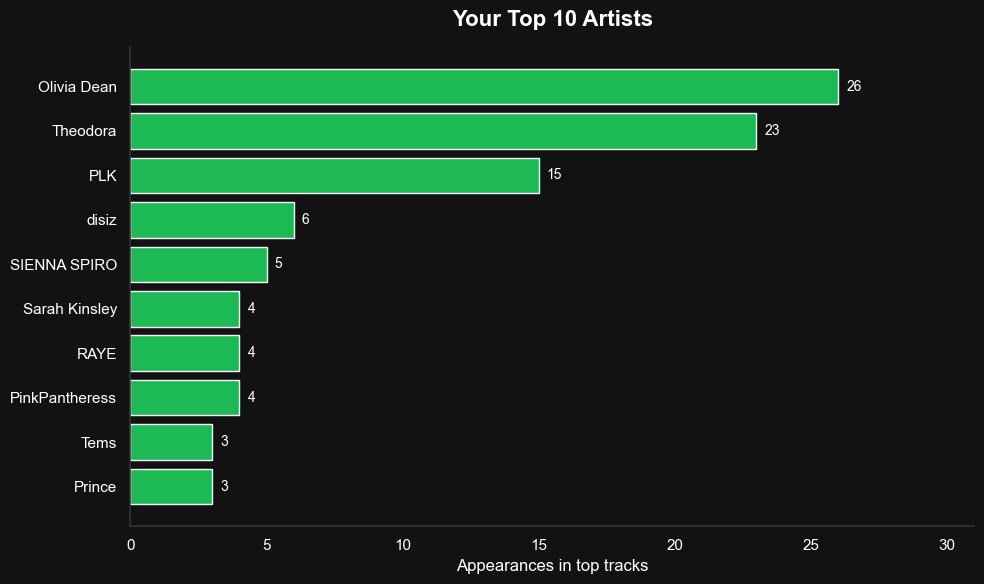

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_artists = df_top_tracks["artist"].value_counts().head(10)

bars = ax.barh(top10_artists.index[::-1], top10_artists.values[::-1], color=SPOTIFY_GREEN)

for bar, val in zip(bars, top10_artists.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", color="white", fontsize=10)

ax.set_title("Your Top 10 Artists", fontsize=16, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Appearances in top tracks", color="white")
ax.set_xlim(0, top10_artists.values.max() + 5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top_artists.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Top 10 tracks by average rank:


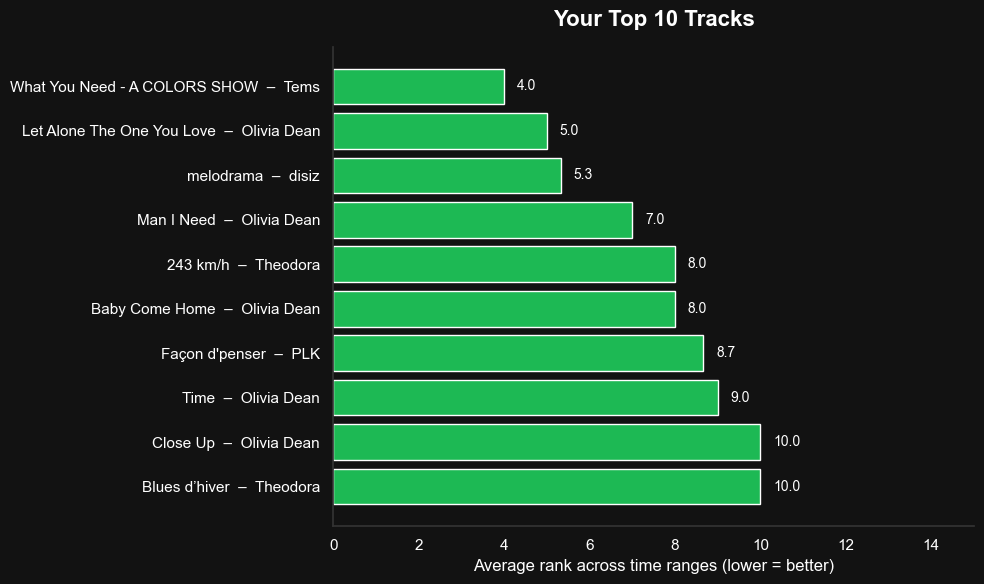

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_tracks = (
    df_top_tracks.groupby(["track", "artist"])["rank"]
    .mean()
    .reset_index(name="avg_rank")
    .sort_values("avg_rank", ascending=True)  # lower rank = better
    .head(10)
)

labels = [f"{row.track}  –  {row.artist}" for _, row in top10_tracks.iterrows()]

# Invert so best (lowest avg rank) is at the top
bars = ax.barh(labels[::-1], top10_tracks["avg_rank"].values[::-1], color=SPOTIFY_GREEN)

for bar, val in zip(bars, top10_tracks["avg_rank"].values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", color="white", fontsize=10)

ax.set_title("Your Top 10 Tracks", fontsize=16, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Average rank across time ranges (lower = better)", color="white")
ax.set_xlim(0, top10_tracks["avg_rank"].max() + 5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top_tracks.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Taste Evolution

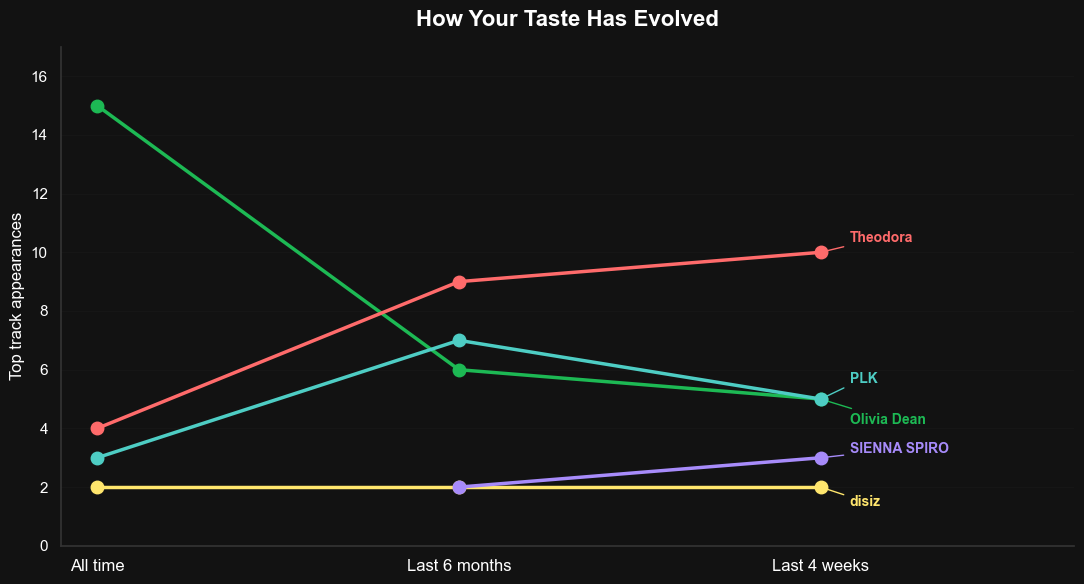

In [22]:
time_ranges = ["long_term", "medium_term", "short_term"]

evolution = []
for tr in time_ranges:
    subset = df_top_tracks[df_top_tracks["time_range"] == tr]
    top8 = subset["artist"].value_counts().head(8).reset_index()  # increased to 8
    top8.columns = ["artist", "count"]
    top8["time_range"] = tr
    evolution.append(top8)

df_evo = pd.concat(evolution)

artists_to_plot = ["Olivia Dean", "Theodora", "PLK", "disiz", "SIENNA SPIRO"]
colors = [SPOTIFY_GREEN, "#FF6B6B", "#4ECDC4", "#FFE66D", "#A78BFA"]

offsets = {
    "Olivia Dean": -0.7,
    "Theodora":     0.5,
    "PLK":          0.7,
    "disiz":       -0.5,
    "SIENNA SPIRO": 0.3
}

fig, ax = plt.subplots(figsize=(11, 6))

for i, artist in enumerate(artists_to_plot):
    subset = df_evo[df_evo["artist"] == artist]
    if subset.empty:
        continue
    x = [time_ranges.index(tr) for tr in subset["time_range"]]
    y = subset["count"].values
    color = colors[i]

    ax.plot(x, y, marker="o", color=color, linewidth=2.5, markersize=9, zorder=3)

    ax.annotate(
        artist,
        xy=(x[-1], y[-1]),
        xytext=(x[-1] + 0.08, y[-1] + offsets.get(artist, 0)),
        color=color, fontsize=10, fontweight="bold", va="center",
        arrowprops=dict(arrowstyle="-", color=color, lw=1)
    )

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([label_map[tr] for tr in time_ranges], fontsize=12)
ax.set_ylabel("Top track appearances", color="white")
ax.set_title("How Your Taste Has Evolved", fontsize=16, fontweight="bold", color="white", pad=15)
ax.set_xlim(-0.1, 2.7)
ax.set_ylim(0, df_evo[df_evo["artist"].isin(artists_to_plot)]["count"].max() + 2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/taste_evolution.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Taste Evolution:

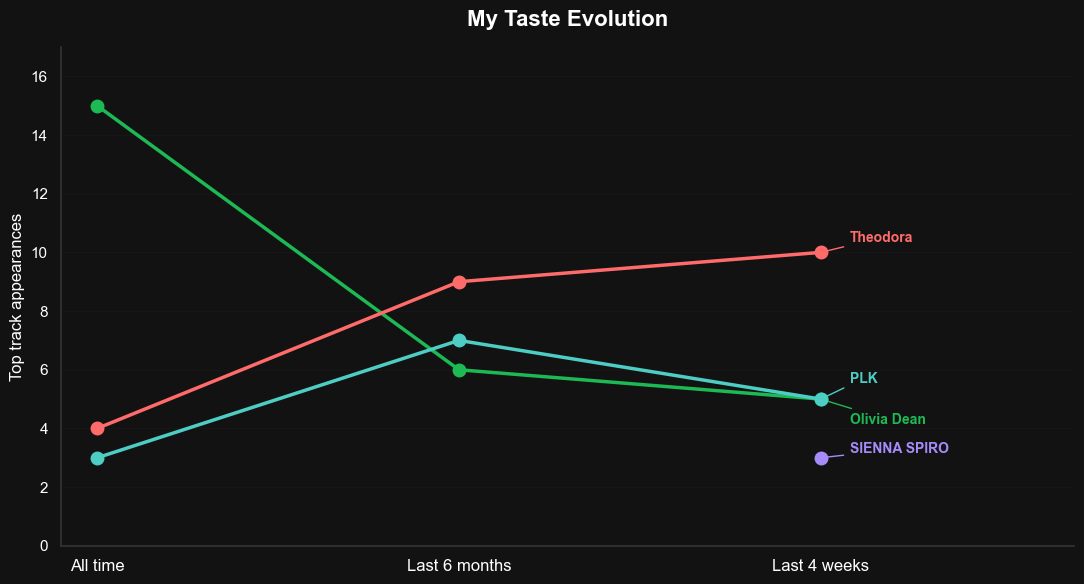

In [21]:
# Focus on artists who appear in at least 2 time ranges for a meaningful story
artists_to_plot = ["Olivia Dean", "Theodora", "PLK", "disiz", "SIENNA SPIRO"]
colors = [SPOTIFY_GREEN, "#FF6B6B", "#4ECDC4", "#FFE66D", "#A78BFA"]

offsets = {
    "Olivia Dean": -0.7,
    "Theodora":     0.5,
    "PLK":          0.7,
    "disiz":       -0.5,
    "SIENNA SPIRO": 0.3
}

fig, ax = plt.subplots(figsize=(11, 6))

for i, artist in enumerate(artists_to_plot):
    subset = df_evo[df_evo["artist"] == artist]
    if subset.empty:
        continue
    x = [time_ranges.index(tr) for tr in subset["time_range"]]
    y = subset["count"].values
    color = colors[i]

    ax.plot(x, y, marker="o", color=color, linewidth=2.5, markersize=9, zorder=3)

    ax.annotate(
        artist,
        xy=(x[-1], y[-1]),
        xytext=(x[-1] + 0.08, y[-1] + offsets.get(artist, 0)),
        color=color, fontsize=10, fontweight="bold", va="center",
        arrowprops=dict(arrowstyle="-", color=color, lw=1)
    )

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([label_map[tr] for tr in time_ranges], fontsize=12)
ax.set_ylabel("Top track appearances", color="white")
ax.set_title("My Taste Evolution", fontsize=16,
             fontweight="bold", color="white", pad=15)
ax.set_xlim(-0.1, 2.7)
ax.set_ylim(0, df_evo[df_evo["artist"].isin(artists_to_plot)]["count"].max() + 2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/taste_evolution.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Most Saved Artists:

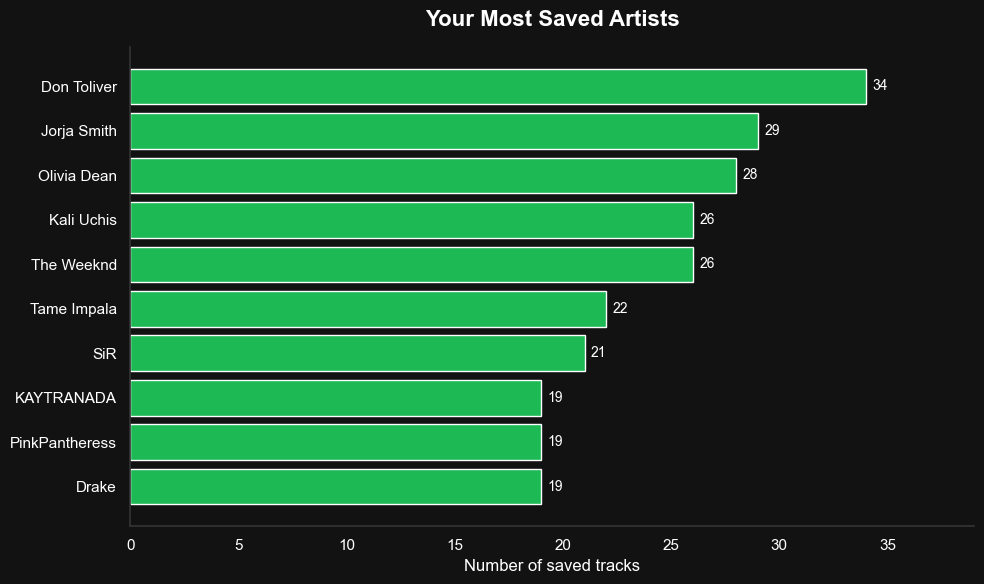

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

top_artists_saved = df_saved["artist"].value_counts().head(10)

bars = ax.barh(top_artists_saved.index[::-1], top_artists_saved.values[::-1], color=SPOTIFY_GREEN)

for bar, val in zip(bars, top_artists_saved.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", color="white", fontsize=10)

ax.set_title("Your Most Saved Artists", fontsize=16, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Number of saved tracks", color="white")
ax.set_xlim(0, top_artists_saved.values.max() + 5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top_artists_saved.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Library Growth Over Time

/var/folders/y4/b6k8_8b167zchxth55msyrvc0000gn/T/ipykernel_1312/3037752258.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_saved["month"] = df_saved["added_at"].dt.to_period("M")


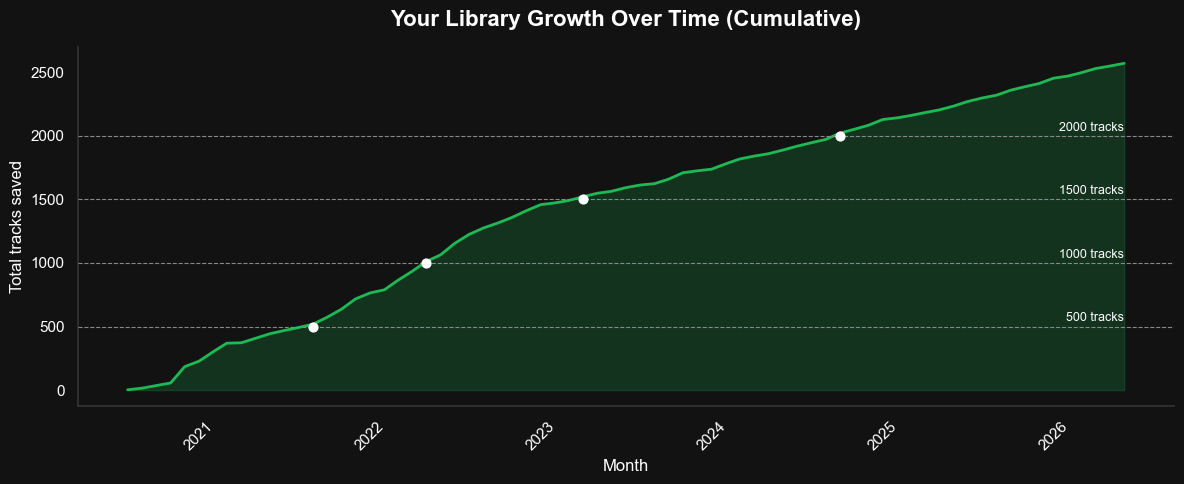

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

df_saved["month"] = df_saved["added_at"].dt.to_period("M")
tracks_per_month = df_saved.groupby("month").size().cumsum()
tracks_per_month.index = tracks_per_month.index.to_timestamp()

ax.plot(tracks_per_month.index, tracks_per_month.values,
        color=SPOTIFY_GREEN, linewidth=2, zorder=3)
ax.fill_between(tracks_per_month.index, tracks_per_month.values,
                alpha=0.2, color=SPOTIFY_GREEN, zorder=2)

for milestone in [500, 1000, 1500, 2000]:
    if milestone <= tracks_per_month.values.max():
        date = tracks_per_month[tracks_per_month >= milestone].index[0]
        ax.axhline(milestone, color="#888888", linewidth=0.8, linestyle="--", zorder=4)
        ax.text(tracks_per_month.index[-1], milestone + 40,
                f"{milestone} tracks", color="white", fontsize=9, ha="right", zorder=5)
        ax.scatter(date, milestone, color="white", s=40, zorder=6)

ax.set_title("Your Library Growth Over Time (Cumulative)", fontsize=16,
             fontweight="bold", color="white", pad=15)
ax.set_xlabel("Month", color="white")
ax.set_ylabel("Total tracks saved", color="white")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/library_growth.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Spotify Wrapped Card

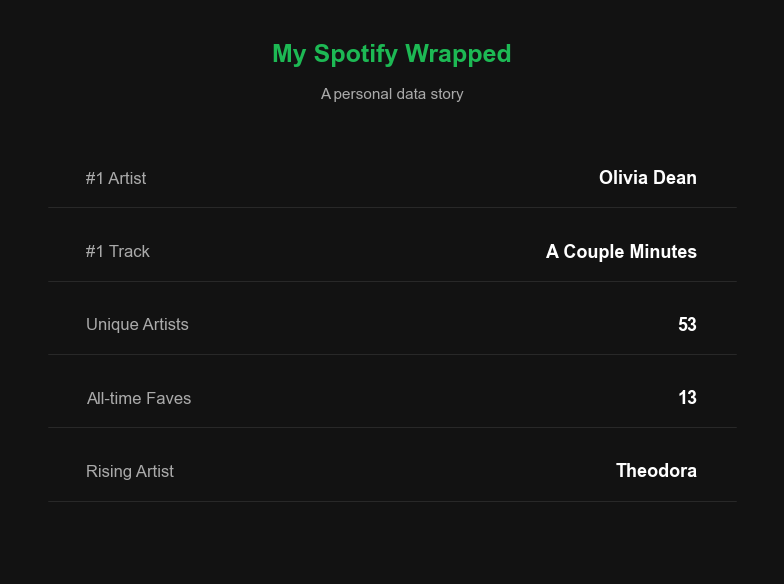

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

fig.patch.set_facecolor("#121212")

stats = [
    ("#1 Artist",      df_top_tracks["artist"].value_counts().index[0]),
    ("#1 Track",       df_top_tracks.groupby("track").size().idxmax()),
    ("Unique Artists", str(df_top_tracks["artist"].nunique())),
    ("All-time Faves", str(len(df_top_tracks[df_top_tracks.groupby("track")["time_range"].transform("count") == 3]["track"].unique()))),
    ("Rising Artist",  "Theodora"),
]

ax.text(5, 9.2, "My Spotify Wrapped", ha="center", va="center",
        fontsize=18, fontweight="bold", color=SPOTIFY_GREEN)
ax.text(5, 8.5, "A personal data story", ha="center", va="center",
        fontsize=11, color="#aaaaaa")

for i, (label, value) in enumerate(stats):
    y = 7 - i * 1.3
    ax.text(1, y, label, fontsize=12, color="#aaaaaa", va="center")
    ax.text(9, y, value, fontsize=13, fontweight="bold",
            color="white", va="center", ha="right")
    ax.axhline(y - 0.5, color="#333333", linewidth=0.5, xmin=0.05, xmax=0.95)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/summary_card.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 5. Key Insights

- **Olivia Dean** is my all-time #1 artist with 31 appearances across top track charts
- **`don Toliver** is my most saved artists - 34 songs of his are saved on my spotify
- **Theodora** is my fastest rising artist — barely in my all-time list but dominating my last 4 weeks
- My library has grown consistently since 2020, reaching **2,571 saved tracks** across **1,014 artists**